## 0. Importing PyTorch and setting up device-agnostic code

In [ ]:
import torch
from torch import nn

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",{device})
print()

if device.type =="cuda":
  print(torch.cuda.get_device_name(0))

Using device: {device(type='cpu')}



In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Training on GPU...Ready for HyperJumo...")
else:
    device = torch.device("cpu")
    print("Training on CPU...May the force be with you...")


Training on CPU...May the force be with you...


## 1. Get Data



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import zipfile
from pathlib import Path

zip_path="/content/drive/MyDrive/Colab Notebooks/supervised.zip"
image_path = Path("/content/data")

with zipfile.ZipFile(zip_path ,"r") as zip_ref:
    zip_ref.extractall(image_path)

print(f"The zip file is extracted to the '{image_path}' directory.")


The zip file is extracted to the '/content/data' directory.


In [ ]:
import os

total_files = 0
for root, dirs, files in os.walk(image_path):
    total_files+= len(files)

print(f"Total number of files found: {total_files}")

Total number of files found: 10001


In [ ]:
for dirpath, dirnames, filenames in os.walk(image_path):
    print(f" There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

 There are 1 directories and 0 images in '/content/data'
 There are 1 directories and 1 images in '/content/data/supervised'
 There are 2 directories and 0 images in '/content/data/supervised/dataset'
 There are 30 directories and 0 images in '/content/data/supervised/dataset/train'
 There are 0 directories and 270 images in '/content/data/supervised/dataset/train/School'
 There are 0 directories and 297 images in '/content/data/supervised/dataset/train/Square'
 There are 0 directories and 369 images in '/content/data/supervised/dataset/train/River'
 There are 0 directories and 234 images in '/content/data/supervised/dataset/train/Center'
 There are 0 directories and 324 images in '/content/data/supervised/dataset/train/Airport'
 There are 0 directories and 306 images in '/content/data/supervised/dataset/train/Mountain'
 There are 0 directories and 315 images in '/content/data/supervised/dataset/train/Commercial'
 There are 0 directories and 279 images in '/content/data/supervised/data

In [ ]:
train_dir = image_path / "supervised/dataset/train"
test_dir = image_path / "supervised/dataset/test"

train_dir ,test_dir

(PosixPath('/content/data/supervised/dataset/train'),
 PosixPath('/content/data/supervised/dataset/test'))

/content/data/supervised/dataset/train/Commercial/commercial_79.jpg
Commercial
Random image path: /content/data/supervised/dataset/train/Commercial/commercial_79.jpg
Image class: Commercial
Image height: 600
Image width: 600


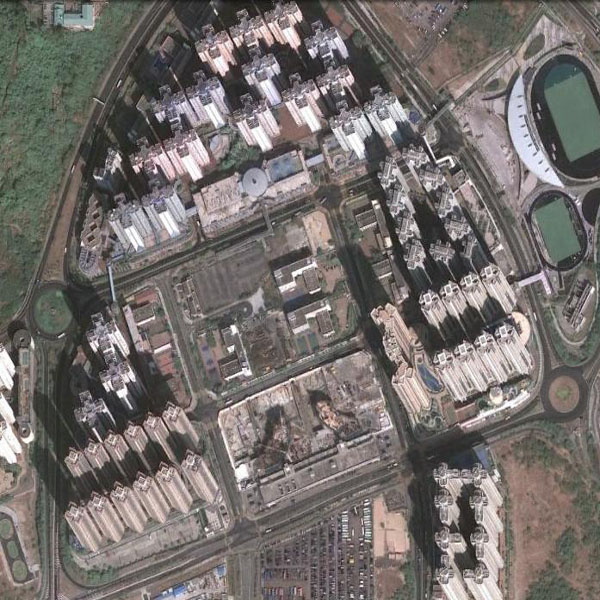

In [ ]:
import random
from PIL import Image

random.seed(42)
image_path_list = list(image_path.glob("*/*/*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
print(random_image_path)

image_class = random_image_path.parent.stem
print(image_class)

img= Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

## 3. Transforming data

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from torchvision import transforms

data_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


In [ ]:
# if isinstance(img, Image.Image) or isinstance(img, np.ndarray):
#     img_tensor = transforms.ToTensor()(img)
# else:
#     img_tensor = img

# Convert PIL Image to PyTorch tensor
img_tensor = transforms.ToTensor()(img)

# Now you can check the min and max values
print(img_tensor.min(), img_tensor.max())



tensor(0.0039) tensor(1.)


In [ ]:
data_transform(img)

tensor([[[-0.0980, -0.2235, -0.2627,  ..., -0.3098, -0.3804, -0.3333],
         [-0.1373, -0.2000, -0.1529,  ..., -0.3098, -0.3333, -0.3020],
         [-0.1608, -0.1294, -0.0667,  ..., -0.2941, -0.3020, -0.2549],
         ...,
         [-0.1216, -0.0667, -0.0275,  ..., -0.0902, -0.0118,  0.0431],
         [-0.1137, -0.0824, -0.0510,  ..., -0.0431, -0.0039, -0.0667],
         [-0.1137, -0.0980, -0.1686,  ..., -0.0902, -0.0980, -0.1294]],

        [[-0.1373, -0.2392, -0.2941,  ..., -0.3020, -0.3412, -0.2941],
         [-0.1529, -0.2314, -0.1843,  ..., -0.2627, -0.2784, -0.2392],
         [-0.1922, -0.1765, -0.1294,  ..., -0.2392, -0.2392, -0.2078],
         ...,
         [-0.1765, -0.1373, -0.1137,  ..., -0.1059, -0.0588, -0.0431],
         [-0.1686, -0.1529, -0.1294,  ..., -0.0902, -0.0667, -0.1451],
         [-0.1608, -0.1608, -0.1843,  ..., -0.1373, -0.1529, -0.1765]],

        [[-0.1529, -0.2706, -0.3020,  ..., -0.3412, -0.3961, -0.3490],
         [-0.1765, -0.2549, -0.2078,  ..., -0

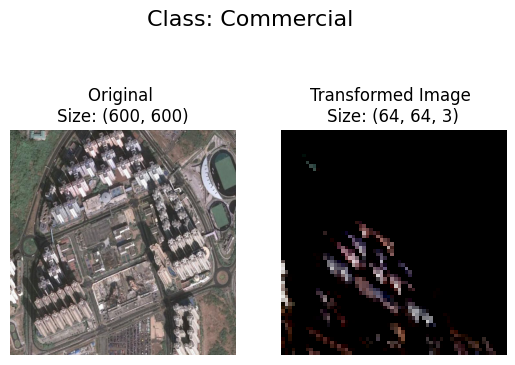

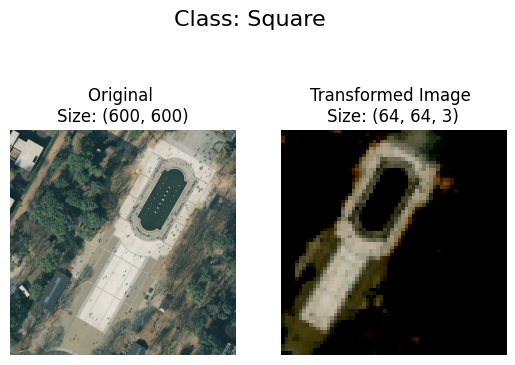

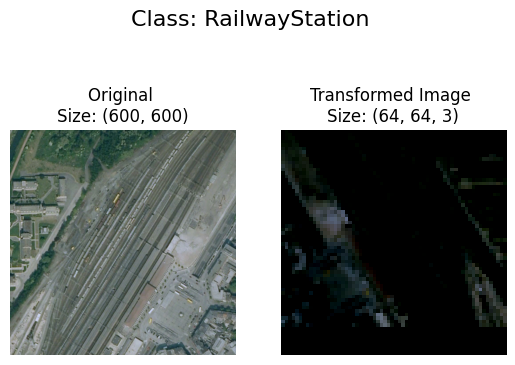

In [ ]:
import torchvision
# Plots a series of random images from image_paths
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
          fig ,ax  = plt.subplots(1,2)
          ax[0].imshow(f)
          ax[0].set_title(f"Original \nSize: {f.size}")
          ax[0].axis("off")
          transformed_image = transform(f).permute(1,2,0).numpy()
          ax[1].imshow(transformed_image)
          ax[1].set_title(f"Transformed Image \nSize: {transformed_image.shape}")
          ax[1].axis("off")

          fig.suptitle(f"Class: {image_path.parent.stem}" ,fontsize=16)

plot_transformed_images(image_path_list, transform=data_transform, n=3)

In [ ]:
train_data = datasets.ImageFolder(root="/content/data/supervised/dataset/train" , transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root="/content/data/supervised/dataset/test" ,transform=data_transform)

train_data ,test_data

(Dataset ImageFolder
     Number of datapoints: 9000
     Root location: /content/data/supervised/dataset/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
                Normalize(mean=[0.5], std=[0.5])
            ),
 Dataset ImageFolder
     Number of datapoints: 1000
     Root location: /content/data/supervised/dataset/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
                Normalize(mean=[0.5], std=[0.5])
            ))

In [ ]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names,class_dict

(['Airport',
  'BareLand',
  'BaseballField',
  'Beach',
  'Bridge',
  'Center',
  'Church',
  'Commercial',
  'DenseResidential',
  'Desert',
  'Farmland',
  'Forest',
  'Industrial',
  'Meadow',
  'MediumResidential',
  'Mountain',
  'Park',
  'Parking',
  'Playground',
  'Pond',
  'Port',
  'RailwayStation',
  'Resort',
  'River',
  'School',
  'SparseResidential',
  'Square',
  'Stadium',
  'StorageTanks',
  'Viaduct'],
 {'Airport': 0,
  'BareLand': 1,
  'BaseballField': 2,
  'Beach': 3,
  'Bridge': 4,
  'Center': 5,
  'Church': 6,
  'Commercial': 7,
  'DenseResidential': 8,
  'Desert': 9,
  'Farmland': 10,
  'Forest': 11,
  'Industrial': 12,
  'Meadow': 13,
  'MediumResidential': 14,
  'Mountain': 15,
  'Park': 16,
  'Parking': 17,
  'Playground': 18,
  'Pond': 19,
  'Port': 20,
  'RailwayStation': 21,
  'Resort': 22,
  'River': 23,
  'School': 24,
  'SparseResidential': 25,
  'Square': 26,
  'Stadium': 27,
  'StorageTanks': 28,
  'Viaduct': 29})

In [ ]:
len(train_data), len(test_data)

(9000, 1000)

In [ ]:
train_data.samples[0]

('/content/data/supervised/dataset/train/Airport/airport_1.jpg', 0)

In [ ]:
img ,label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[-0.6706, -0.7020, -0.7176,  ...,  0.5059,  0.5059,  0.4588],
         [-0.6706, -0.7176, -0.7333,  ...,  0.5216,  0.4902,  0.4745],
         [-0.5451, -0.4510, -0.3569,  ...,  0.5059,  0.5059,  0.5059],
         ...,
         [ 0.6784,  0.6784,  0.6157,  ...,  0.5216,  0.4902,  0.4745],
         [ 0.6000,  0.6157,  0.5843,  ...,  0.4275,  0.4431,  0.3490],
         [ 0.4902,  0.5216,  0.5373,  ...,  0.4588,  0.3333,  0.3020]],

        [[-0.6235, -0.6549, -0.6549,  ...,  0.3020,  0.3176,  0.3176],
         [-0.6235, -0.6706, -0.6706,  ...,  0.3176,  0.2863,  0.3176],
         [-0.5137, -0.4353, -0.3412,  ...,  0.3020,  0.3176,  0.3490],
         ...,
         [ 0.6314,  0.6000,  0.5373,  ...,  0.3490,  0.3333,  0.3490],
         [ 0.5529,  0.5529,  0.5216,  ...,  0.3020,  0.3333,  0.2392],
         [ 0.4588,  0.4745,  0.4902,  ...,  0.3490,  0.2078,  0.1765]],

        [[-0.4510, -0.4824, -0.4824,  ...,  0.1451,  0.1922,  0.2078],
         [-0.4510, -0.4980, -0.

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


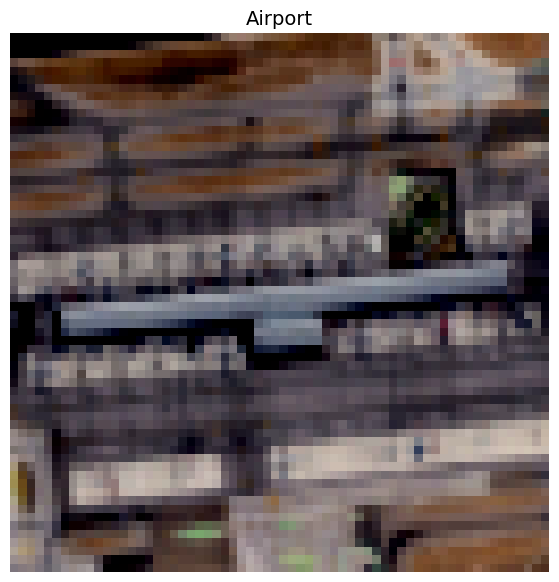

In [ ]:
img_permute = img.permute(1,2,0)

# Print out different shape
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

### 4.1 Turn loaded images into `DataLoader`'s

In [ ]:
num_workers =os.cpu_count()
torch.manual_seed(42)

train_dataloader = DataLoader(dataset=train_data ,num_workers=num_workers, batch_size=32, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, num_workers=num_workers, batch_size=32, shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x799c51a02bc0>,
 <torch.utils.data.dataloader.DataLoader at 0x799d1ed2d7b0>)

In [ ]:
# # Veriyi ve etiketleri elde etmek
# x_train, x_temp ,y_train, y_temp = next(iter(train_dataloader))
# z_val,x_test ,y_val ,y_test= next(iter(test_dataloader))

# print(f"Training Set: {len(x_train)} samples")
# print(f"Validation Set: {len(x_val)} samples")
# print(f"Test Set: {len(x_test)} samples")

# print("x_train boyutu:", x_train.shape)
# print("x_test boyutu:", x_test.shape)

In [ ]:
len(train_dataloader), len(test_dataloader)

(282, 32)

In [ ]:
# custom_image_path = image_path / '/content/data/supervised/dataset/train/Airport/airport_1.jpg'

# custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

img, label = next(iter(train_dataloader))

print(f"Image shape: {img.shape}")
print(f"Label shape: {label.shape}")


Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


In [ ]:
image_path_list = list(image_path.glob("*/*/*/*/*.jpg"))
image_path_list[:10]

[PosixPath('/content/data/supervised/dataset/train/School/school_156.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_93.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_50.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_2.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_208.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_64.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_267.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_177.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_225.jpg'),
 PosixPath('/content/data/supervised/dataset/train/School/school_169.jpg')]

## 6. Model:TinyVGG with Data Augmentation

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*13*13, # because of shape error
                      out_features=output_shape))

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))
        return x

In [ ]:
torch.manual_seed(42)
model = TinyVGG(input_shape=3, hidden_units =10, output_shape=len(train_data.classes)).to(device)

model

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=30, bias=True)
  )
)

In [ ]:
with torch.no_grad():
    sample_image = torch.randn(1, 3, 224, 224).to(device)
    print(model.conv_block_1(sample_image).shape)
    print(model.conv_block_2(model.conv_block_1(sample_image)).shape)

torch.Size([1, 10, 110, 110])
torch.Size([1, 10, 53, 53])


In [ ]:
# Get a single image batch
img_batch, label_batch = next(iter(train_dataloader))
img_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
model(img_batch.to(device))

tensor([[-7.4720e-03, -2.5878e-03,  2.0737e-02, -2.2458e-02,  4.1621e-02,
          3.0428e-02,  4.6977e-03,  1.1397e-01, -1.5950e-02, -7.7031e-02,
         -9.2646e-03,  7.5514e-02, -7.0441e-03, -3.9388e-02,  2.3565e-02,
          9.3595e-03, -1.5221e-02, -2.2619e-03,  9.4739e-02, -6.9244e-03,
          1.1229e-01, -2.4596e-02,  5.1620e-02, -4.0579e-02, -4.0393e-02,
          1.5485e-02, -6.5227e-03,  5.6866e-02, -1.2061e-02,  5.4560e-03],
        [-2.0045e-03,  8.4975e-03,  1.0222e-02, -2.5400e-02,  2.4870e-02,
          1.4218e-02,  1.4645e-02,  9.6325e-02,  1.8851e-02, -8.2041e-02,
          5.3204e-03,  5.7205e-02,  2.2188e-03, -1.5638e-02,  2.9974e-02,
          3.4874e-02, -1.9014e-02,  7.6981e-03,  9.3450e-02, -1.3584e-02,
          1.0053e-01, -2.1481e-02,  4.8180e-02, -3.6682e-02, -3.9707e-02,
          1.2161e-02, -2.2013e-02,  5.4091e-02,  8.3186e-03, -1.8675e-02],
        [-2.6082e-03,  8.0792e-03,  1.9797e-02, -1.6444e-02,  2.6460e-02,
          2.5397e-02,  1.3034e-02,  

In [ ]:
# Install torchinfo if it's not available, import it if it is
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model, input_size=[1, 3, 64, 64]) # do a test pass through of an example input size

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 30]                   --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer:torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X) # output model logits
        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item())/len(test_pred_labels)

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:
# from tqdm.auto import tqdm

# # 1. Take in various parameters required for training and test steps
# def train(model: torch.nn.Module,
#           train_dataloader: torch.utils.data.DataLoader,
#           test_dataloader: torch.utils.data.DataLoader,
#           optimizer: torch.optim.Optimizer,
#           loss_fn: torch.nn.Module,
#           epochs: int = 5):

#     # 2. Create empty results dictionary
#     results = {"train_loss": [],
#         "train_acc": [],
#         "test_loss": [],
#         "test_acc": []
#     }

#     # 3. Loop through training and testing steps for a number of epochs
#     for epoch in tqdm(range(epochs)):
#         train_loss, train_acc = train_step(model=model,
#                                            dataloader=train_dataloader,
#                                            loss_fn=loss_fn,
#                                            optimizer=optimizer)
#         test_loss, test_acc = test_step(model=model,
#             dataloader=test_dataloader,
#             loss_fn=loss_fn)

#         # 4. Print out what's happening
#         print(
#             f"Epoch: {epoch+1} | "
#             f"train_loss: {train_loss:.4f} | "
#             f"train_acc: {train_acc:.4f} | "
#             f"test_loss: {test_loss:.4f} | "
#             f"test_acc: {test_acc:.4f}"
#         )

#         # 5. Update results dictionary
#         # Ensure all data is moved to CPU and converted to float for storage
#         results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
#         results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
#         results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
#         results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

#     # 6. Return the filled results at the end of the epochs
#     return results

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],}


    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        # Perform training step
        train_loss, train_acc = train_step(model=model,
                                                          dataloader=train_dataloader,
                                                          loss_fn=loss_fn,
                                                          optimizer=optimizer)
        # Perform test step
        test_loss, test_acc = test_step(model=model,
                                                      dataloader=test_dataloader,
                                                      loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f} | "
        )

        # 5. Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)

        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)


    # 6. Return the filled results at the end of the epochs
    return results

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 7

# Recreate an instance of TinyVGG
model = TinyVGG(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=100,
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model
model_results = train(model=model,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.8665 | train_acc: 0.1687 | test_loss: 2.6186 | test_acc: 0.2520 | 
Epoch: 2 | train_loss: 2.4098 | train_acc: 0.3018 | test_loss: 2.1920 | test_acc: 0.3672 | 
Epoch: 3 | train_loss: 2.1239 | train_acc: 0.3850 | test_loss: 2.0232 | test_acc: 0.4014 | 
Epoch: 4 | train_loss: 1.8974 | train_acc: 0.4469 | test_loss: 1.9485 | test_acc: 0.4258 | 
Epoch: 5 | train_loss: 1.7467 | train_acc: 0.4904 | test_loss: 1.7957 | test_acc: 0.4922 | 
Epoch: 6 | train_loss: 1.6383 | train_acc: 0.5224 | test_loss: 1.7478 | test_acc: 0.4736 | 
Epoch: 7 | train_loss: 1.5101 | train_acc: 0.5571 | test_loss: 1.7051 | test_acc: 0.5029 | 
Total training time: 7211.373 seconds


In [ ]:
model_results

{'train_loss': [2.8664986393975873,
  2.4098062384213117,
  2.1238571464592684,
  1.89736363481968,
  1.7467413760246115,
  1.638300118716896,
  1.5100660622119904],
 'train_acc': [0.1686613475177305,
  0.3017508865248227,
  0.3849734042553192,
  0.44691932624113473,
  0.4903590425531915,
  0.5223847517730497,
  0.5570700354609929],
 'test_loss': [2.618605323135853,
  2.191972963511944,
  2.0231692288070917,
  1.9484926518052816,
  1.7957411147654057,
  1.747808439657092,
  1.7050872351974249],
 'test_acc': [0.251953125,
  0.3671875,
  0.4013671875,
  0.42578125,
  0.4921875,
  0.4736328125,
  0.5029296875]}

In [ ]:
from typing import Tuple, Dict, List
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary."""

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

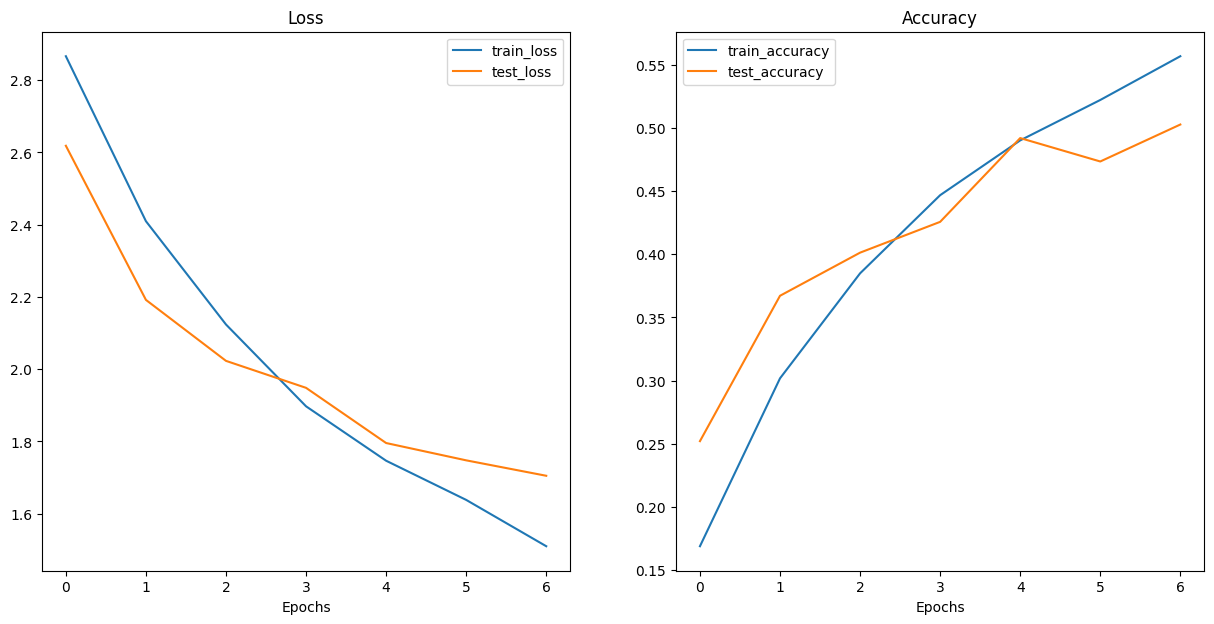

In [ ]:
plot_loss_curves(model_results)

In [ ]:
from sklearn.metrics import accuracy_score
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.5030


Test Accuracy: 50.60%


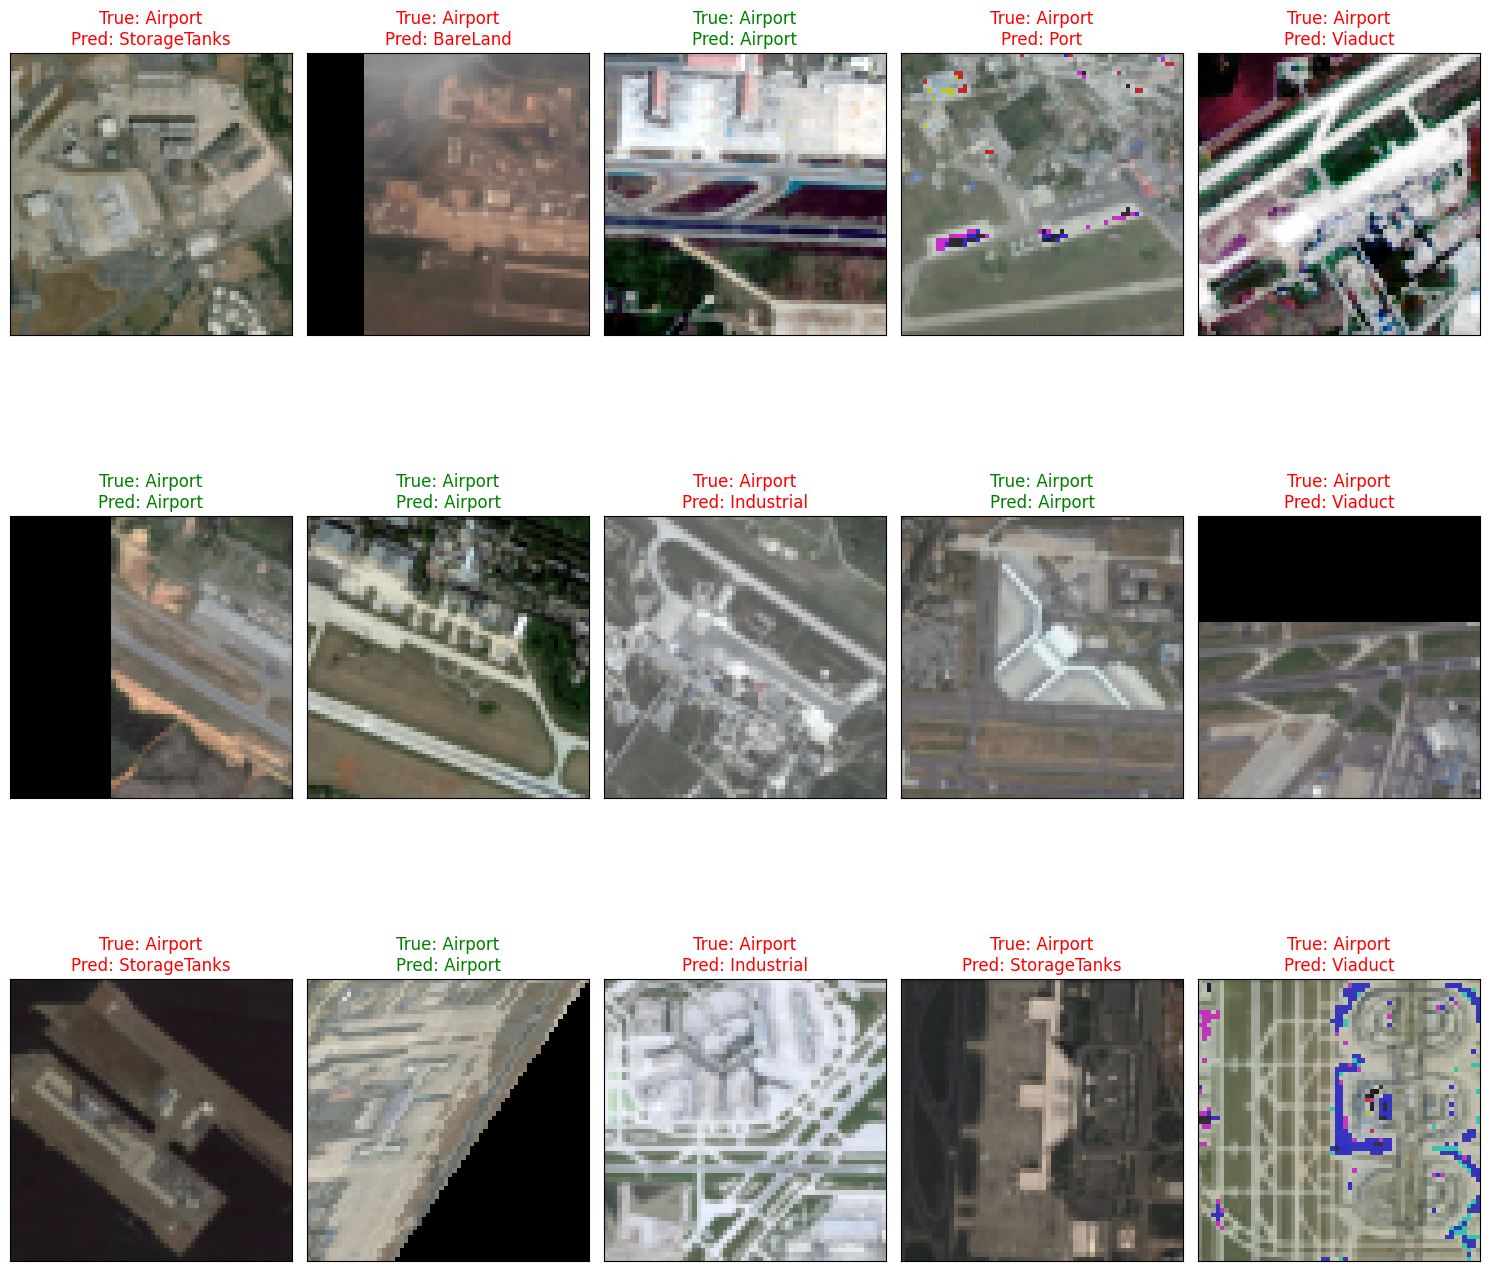

In [ ]:
from torchvision import models

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model.to(device)

class_names = test_dataloader.dataset.classes

model.eval()
correct = 0
total = 0
all_images = []
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_images.extend(images.cpu())
        all_labels.extend(labels.cpu())
        all_predictions.extend(predicted.cpu())

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

plt.figure(figsize=(15, 15))

for i in range(min(15, len(all_images))):
    plt.subplot(3, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    image = all_images[i].permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
    image = image * 0.5 + 0.5

    true_label = class_names[all_labels[i].item()]
    pred_label = class_names[all_predictions[i].item()]


    plt.imshow(image)
    plt.title(f"True: {true_label}\nPred: {pred_label}",
              color="green" if true_label == pred_label else "red")

plt.tight_layout()
plt.show()
